# 电商用户 RFM 分析

基于 Recency（最近购买）、Frequency（购买频率）、Monetary（消费金额）对用户进行价值分层。

## 1. 导入库与配置

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

fm._load_fontmanager(try_read_cache=False)
plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('darkgrid')

## 2. 加载数据

In [2]:
import sys
sys.path.append('../python')

from mysql_connect import get_engine, read_rfm_data, read_users, read_products


engine = get_engine()


df_orders = read_rfm_data(engine)

df_users = read_users(engine)

df_products = read_products(engine)


print(f'用户数: {len(df_users)}')
print(f'商品数: {len(df_products)}')
print(f'订单数: {len(df_orders)}')


df_orders.head()

print(f'用户数: {len(df_users)}')
print(f'商品数: {len(df_products)}')
print(f'订单数: {len(df_orders)}')

用户数: 5000
商品数: 200
订单数: 50000
用户数: 5000
商品数: 200
订单数: 50000


In [3]:
df_users.head()

,user_id,user_name,age,city,register_time
0,1,暨伟,56,杭州,2025-03-16
1,2,查萍,46,西安,2024-01-01
2,3,成宁,32,深圳,2025-08-03
3,4,苗健,60,武汉,2023-02-19
4,5,山伟,25,成都,2023-04-02


In [4]:
df_products.head()

,product_id,product_name,category,price
0,1,电脑商品1,电脑,2372.37
1,2,手机商品2,手机,4164.08
2,3,美妆商品3,美妆,126.64
3,4,家电商品4,家电,1400.94
4,5,家电商品5,家电,62.15


In [5]:
df_orders.head()

,user_id,order_id,amount,order_time
0,403,1,2127.54,2025-08-13
1,4710,2,18883.96,2025-08-02
2,2671,3,12791.55,2025-02-21
3,1802,4,9748.40,2025-01-31
4,2651,5,10353.50,2024-04-19


## 3. 数据清洗与预处理

In [6]:
# 检查缺失值
print('缺失值统计：')
print(df_orders.isnull().sum())

缺失值统计：
user_id       0
order_id      0
amount        0
order_time    0
dtype: int64


In [7]:
# 日期转换
df_orders['order_time'] = pd.to_datetime(df_orders['order_time'])
df_users['register_time'] = pd.to_datetime(df_users['register_time'])

# 剔除金额异常订单（<=0）
df_orders = df_orders[df_orders['amount'] > 0].copy()
print(f'清洗后订单数: {len(df_orders)}')

清洗后订单数: 50000


In [8]:
# 订单数据概览
print(f'订单日期范围: {df_orders["order_time"].min()} ~ {df_orders["order_time"].max()}')
print(f'有下单行为的用户数: {df_orders["user_id"].nunique()}')
print(f'客单价均值: ¥{df_orders["amount"].mean():.2f}')
print(f'订单金额中位数: ¥{df_orders["amount"].median():.2f}')

订单日期范围: 2024-01-01 00:00:00 ~ 2026-06-29 00:00:00
有下单行为的用户数: 5000
客单价均值: ¥7968.58
订单金额中位数: ¥6660.96


## 4. 计算 RFM 指标

In [9]:
# 以数据最大日期 + 1 天作为分析快照日
snapshot_date = df_orders['order_time'].max() + timedelta(days=1)
print(f'快照日期: {snapshot_date}')

rfm = df_orders.groupby('user_id').agg(
    Recency=('order_time', lambda x: (snapshot_date - x.max()).days),
    Frequency=('order_id', 'count'),
    Monetary=('amount', 'sum')
).reset_index()

print(f'\nRFM 基础统计：')
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

快照日期: 2026-06-30 00:00:00



RFM 基础统计：
           Recency    Frequency       Monetary
count  5000.000000  5000.000000    5000.000000
mean     67.447000    10.000000   79685.830096
std      73.686367     3.117618   31185.739442
min       1.000000     1.000000      62.150000
25%      17.000000     8.000000   57308.287500
50%      43.000000    10.000000   76779.400000
75%      91.000000    12.000000   99042.610000
max     863.000000    24.000000  221234.650000


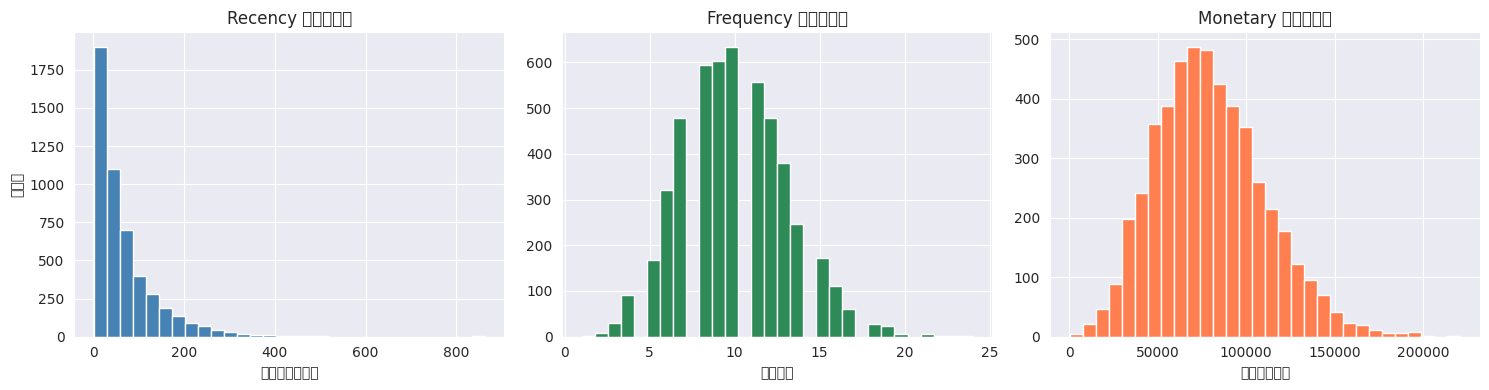

In [10]:
# RFM 分布直方图
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(rfm['Recency'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Recency 分布（天）')
axes[0].set_xlabel('距上次购买天数')
axes[0].set_ylabel('用户数')

axes[1].hist(rfm['Frequency'], bins=30, color='seagreen', edgecolor='white')
axes[1].set_title('Frequency 分布（次）')
axes[1].set_xlabel('购买次数')

axes[2].hist(rfm['Monetary'], bins=30, color='coral', edgecolor='white')
axes[2].set_title('Monetary 分布（元）')
axes[2].set_xlabel('累计消费金额')

plt.tight_layout()
plt.savefig('../rfm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. RFM 打分（五分位法）

In [11]:
# 先 rank 再 qcut，避免 qcut 因重复值报错
rfm['R_rank'] = rfm['Recency'].rank(method='first')
rfm['F_rank'] = rfm['Frequency'].rank(method='first')
rfm['M_rank'] = rfm['Monetary'].rank(method='first')

# R：越低越好，反向打分（5=最近活跃）
rfm['R_Score'] = pd.qcut(rfm['R_rank'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)
# F：越高越好
rfm['F_Score'] = pd.qcut(rfm['F_rank'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)
# M：越高越好
rfm['M_Score'] = pd.qcut(rfm['M_rank'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm.drop(['R_rank', 'F_rank', 'M_rank'], axis=1, inplace=True)

print('RFM 打分结果（前10名）：')
print(rfm.head(10))

RFM 打分结果（前10名）：
   user_id  Recency  Frequency   Monetary  R_Score  F_Score  M_Score
0        1       15         15   90794.75        4        5        4
1        2       87          6   51775.78        2        1        1
2        3      226          4   40333.11        1        1        1
3        4       39         14  150219.96        3        5        5
4        5       98          6   61259.79        2        1        2
5        6       62          9   72649.91        2        2        3
6        7       13         12  100230.35        5        4        4
7        8        9         14   99922.40        5        5        4
8        9       28          9   71458.86        4        2        3
9       10      123          9   74159.66        1        2        3


## 6. 用户分层

In [12]:
def rfm_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 3 and f >= 3 and m >= 3:
        return '核心客户'
    elif r >= 3 and f < 3 and m >= 3:
        return '高潜力客户'
    elif r < 3 and f >= 3 and m >= 3:
        return '需挽留客户'
    elif r < 3 and f < 3 and m >= 3:
        return '需召回客户'
    elif r >= 3 and f >= 3 and m < 3:
        return '活跃用户'
    elif r >= 3 and f < 3 and m < 3:
        return '新晋用户'
    elif r < 3 and f >= 3 and m < 3:
        return '沉睡用户'
    else:
        return '流失用户'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

print('各层级用户数量：')
print(rfm['Segment'].value_counts())

各层级用户数量：
Segment
核心客户     1684
需挽留客户     794
流失用户      758
新晋用户      720
活跃用户      330
高潜力客户     266
需召回客户     256
沉睡用户      192
Name: count, dtype: int64


## 7. 可视化分析

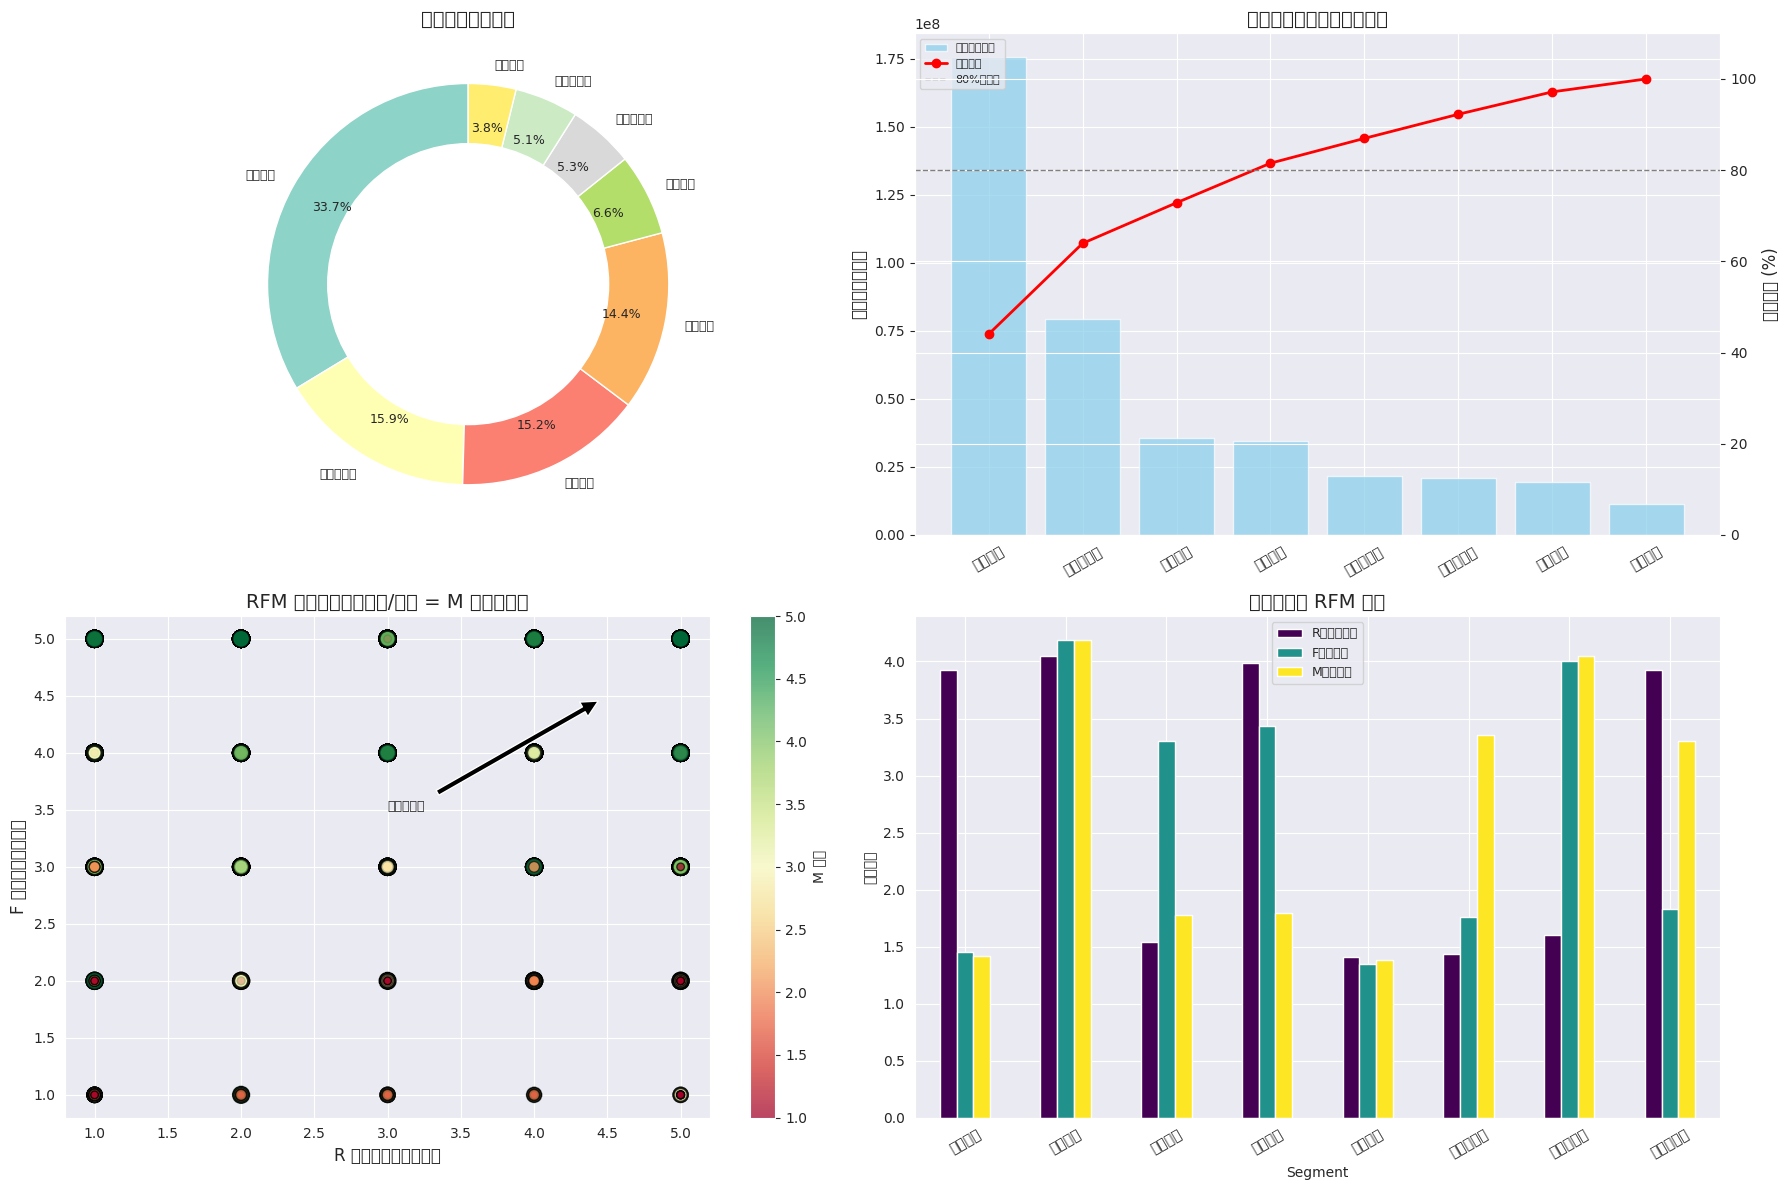

高清分析图表已保存为 Ecommerce_RFM_Analysis.png


In [13]:
plt.close('all')
sns.set_style('darkgrid')
fig = plt.figure(figsize=(18, 12))

# ---- 图1：用户分层占比环形图 ----
ax1 = fig.add_subplot(2, 2, 1)
seg_counts = rfm['Segment'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(seg_counts)))
wedges, texts, autotexts = ax1.pie(
    seg_counts.values, labels=seg_counts.index,
    autopct='%1.1f%%', pctdistance=0.78,
    colors=colors, startangle=90, textprops={'fontsize': 9}
)
ax1.add_artist(plt.Circle((0, 0), 0.70, fc='white'))
ax1.set_title('用户分层人数占比', fontsize=14)

# ---- 图2：各层消费贡献帕累托图 ----
ax2 = fig.add_subplot(2, 2, 2)
monetary_sum = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
ax2.bar(monetary_sum.index, monetary_sum.values, color='skyblue', alpha=0.7, label='分层总消费额')
ax2.set_ylabel('总消费额（元）', fontsize=12)
ax2.tick_params(axis='x', rotation=30)

ax2b = ax2.twinx()
cum_pct = monetary_sum.cumsum() / monetary_sum.sum() * 100
ax2b.plot(monetary_sum.index, cum_pct, color='red', marker='o', linewidth=2, label='累积占比')
ax2b.set_ylabel('累积占比 (%)', fontsize=12)
ax2b.set_ylim(0, 110)
ax2b.axhline(y=80, color='gray', linestyle='--', linewidth=1, label='80%营收线')

h1, l1 = ax2.get_legend_handles_labels()
h2, l2 = ax2b.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=8)
ax2.set_title('各分层消费贡献与累积占比', fontsize=14)

# ---- 图3：RFM 散点图（R vs F，颜色/大小代表 M） ----
ax3 = fig.add_subplot(2, 2, 3)
scatter = ax3.scatter(
    rfm['R_Score'], rfm['F_Score'],
    c=rfm['M_Score'], cmap='RdYlGn',
    s=rfm['M_Score'] * 30, alpha=0.7, edgecolors='k'
)
ax3.set_xlabel('R 得分（越高越活跃）', fontsize=12)
ax3.set_ylabel('F 得分（购买频次）', fontsize=12)
ax3.set_title('RFM 分布散点图（颜色/大小 = M 消费金额）', fontsize=14)
ax3.grid(True)
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('M 得分', fontsize=10)
ax3.annotate('核心客户区', xy=(4.5, 4.5), xytext=(3.0, 3.5),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=9)

# ---- 图4：各层平均 RFM 得分 ----
ax4 = fig.add_subplot(2, 2, 4)
seg_avg = rfm.groupby('Segment')[['R_Score', 'F_Score', 'M_Score']].mean()
seg_avg.plot(kind='bar', ax=ax4, colormap='viridis')
ax4.set_title('各分层平均 RFM 得分', fontsize=14)
ax4.set_ylabel('平均得分')
ax4.tick_params(axis='x', rotation=30)
ax4.legend(['R（活跃度）', 'F（频次）', 'M（金额）'], fontsize=9)

plt.tight_layout()
plt.savefig('../Ecommerce_RFM_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print('高清分析图表已保存为 Ecommerce_RFM_Analysis.png')

## 8. 汇总统计与运营建议

In [14]:
summary = rfm.groupby('Segment').agg(
    用户数=('user_id', 'count'),
    平均消费金额=('Monetary', 'mean'),
    总消费占比=('Monetary', lambda x: round(x.sum() / rfm['Monetary'].sum() * 100, 2))
).round(2).sort_values('平均消费金额', ascending=False)

print(summary)

          用户数     平均消费金额  总消费占比
Segment                        
核心客户     1684  104208.26  44.04
需挽留客户     794   99886.30  19.91
需召回客户     256   82273.76   5.29
高潜力客户     266   81478.88   5.44
活跃用户      330   59271.41   4.91
沉睡用户      192   58933.28   2.84
新晋用户      720   48019.45   8.68
流失用户      758   46765.83   8.90


In [15]:

# 各层级运营策略建议
strategies = {
    '核心客户':   'VIP 专属服务 + 新品优先体验 + 年度回馈活动，重点维系关系',
    '高潜力客户': '推荐高附加值商品 + 组合优惠套餐，提升客单价',
    '需挽留客户': '一对一沟通 + 大额专属优惠券 + 会员权益提醒',
    '需召回客户': '定向推送 + 限时大促 + 召回专属折扣',
    '活跃用户':   '引导升级消费 + 关联推荐 + 积分加速',
    '新晋用户':   '新手礼包 + 首单优惠 + 引导收藏加购',
    '沉睡用户':   '低价爆款唤醒 + 短信/App推送 + 签到有礼',
    '流失用户':   '沉默成本评估 + 选择性放弃或最后召回尝试'
}

print('=' * 55)
for seg in summary.index:
    cnt = int(summary.loc[seg, '用户数'])
    print(f'\n【{seg}】（{cnt} 人）')
    print(f'  策略：{strategies.get(seg, "持续观察")}')

print('\n' + '=' * 55)
print('分析完成！')


【核心客户】（1684 人）
  策略：VIP 专属服务 + 新品优先体验 + 年度回馈活动，重点维系关系

【需挽留客户】（794 人）
  策略：一对一沟通 + 大额专属优惠券 + 会员权益提醒

【需召回客户】（256 人）
  策略：定向推送 + 限时大促 + 召回专属折扣

【高潜力客户】（266 人）
  策略：推荐高附加值商品 + 组合优惠套餐，提升客单价

【活跃用户】（330 人）
  策略：引导升级消费 + 关联推荐 + 积分加速

【沉睡用户】（192 人）
  策略：低价爆款唤醒 + 短信/App推送 + 签到有礼

【新晋用户】（720 人）
  策略：新手礼包 + 首单优惠 + 引导收藏加购

【流失用户】（758 人）
  策略：沉默成本评估 + 选择性放弃或最后召回尝试

分析完成！
